# Index Module

In [1]:
%%capture
%pip install swifter # first time installation

In [2]:
import json
import numpy as np
import pandas as pd
import swifter
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

## Functions

In [3]:
def load_json(
    path: str
) -> list:

    with open(path, "r", encoding="utf-8") as file:
        output = json.load(file)

    return output

In [4]:
def extract_emotions(
    id: str,
    json_data: list
):
    for item in json_data[:]:  # Iterate over a copy to avoid skipping elements
        if item['id'] == str(id):
            try:
                if isinstance(item['content'], dict):
                    output = sorted(list(set(i for sublist in item['content']['emotions'] for i in sublist)))
                else:
                    output = None
                
                # Remove processed item from list
                json_data.remove(item)  

                return output
            except Exception as e:
                print(f"Error processing item: {item}, Error: {e}")

    return None  # Return None if no match is found

In [5]:
def extract_topics(
    id: str,
    json_data: list
):
    for item in json_data[:]:  # Iterate over a copy to avoid skipping elements
        if item['id'] == str(id):
            try:
                if isinstance(item['content'], dict):
                    output = sorted(item['content']['topics'])
                else:
                    output = None
                
                # Remove processed item from list
                json_data.remove(item)  

                return output
            except Exception as e:
                print(f"Error processing item: {item}, Error: {e}")

    return None  # Return None if no match is found

In [6]:
plutchik = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

def create_col_from_emo(
    data: pd.DataFrame,
    cols: list = plutchik
)-> pd.DataFrame:

    df = deepcopy(data)

    # Create separate columns using .map()
    for emotion in cols:
        df[emotion] = df['emotions'].map(lambda x: 1 if isinstance(x, list) and emotion in x else 0)

    return df

In [7]:
topic_list = ['damages', 'hurricane advice', 'hurricane relief services', 'personal opinion', 'weather information', 'other']

def create_col_from_topic(
    data: pd.DataFrame,
    cols: list = topic_list
)-> pd.DataFrame:

    df = deepcopy(data)

    # Create separate columns using .map()
    for topic in cols:
        df[topic] = df['topics'].map(lambda x: 1 if isinstance(x, list) and topic in x else 0)

    return df

In [32]:
import matplotlib.patches as patches

# Define emotion groups and their colors
emocols = ['date', 'anger', 'disgust', 'fear', 'sadness', 'anticipation', 'joy', 'trust', 'surprise']
emocolours = {
    'joy': '#023047',
    'trust': '#126782',
    'anticipation': '#219EBC',
    'surprise': '#58B4D1',
    'anger': '#B62B2B',
    'fear': '#D42929',
    'disgust': '#F04242',
    'sadness': '#FF8787'
}

# Define topic groups and their colors
topiccols = ['date', 'damages', 'hurricane advice', 'hurricane relief services', 'personal opinion', 'weather information']
topiccolours = {
    'damages': '#B62B2B',
    'hurricane advice': '#fb8500',
    'hurricane relief services': '#219ebc',
    'personal opinion': '#ffb703',
    'weather information': '#023047',
    #'other': '#6c757d'
}

def plot_stack100(
    data1: pd.DataFrame,
    data2: pd.DataFrame,
    data3: pd.DataFrame,
    data4: pd.DataFrame,
    datatype: str,
    legend_cols: int = 8,
    legend_add_gap: float = 0.0
):
    if datatype == 'emotions':
        columns = emocols
        colours = emocolours
    
    if datatype == 'topics':
        columns = topiccols
        colours = topiccolours

    df1 = deepcopy(data1)
    df2 = deepcopy(data2)
    df3 = deepcopy(data3)
    df4 = deepcopy(data4)
    df1 = df1[columns]
    df2 = df2[columns]
    df3 = df3[columns]
    df4 = df4[columns]

    # Set 'date' as index
    df1['date'] = pd.to_datetime(df1['date'], format='%Y-%m-%d')
    df1.set_index('date', inplace=True)
    df2['date'] = pd.to_datetime(df2['date'], format='%Y-%m-%d')
    df2.set_index('date', inplace=True)
    df3['date'] = pd.to_datetime(df3['date'], format='%Y-%m-%d')
    df3.set_index('date', inplace=True)
    df4['date'] = pd.to_datetime(df4['date'], format='%Y-%m-%d')
    df4.set_index('date', inplace=True)

    plt.rcParams.update({'font.size': 18})

    # Create figure with two subplots (side by side)
    fig, (ax1, ax3, ax5, ax7) = plt.subplots(1, 4, figsize=(20, 4), sharey=True, gridspec_kw={'wspace': 0.05})

    # Normalize values so each row sums to 1 (100% stacked)
    df1_normalized = df1.div(df1.sum(axis=1), axis=0) * 100
    df2_normalized = df2.div(df2.sum(axis=1), axis=0) * 100
    df3_normalized = df3.div(df3.sum(axis=1), axis=0) * 100
    df4_normalized = df4.div(df4.sum(axis=1), axis=0) * 100

    # Plot 100% stacked bar chart
    df1_normalized.plot(kind='bar', stacked=True, ax=ax1, width=.8, color=[colours[col] for col in df1_normalized.columns])
    df2_normalized.plot(kind='bar', stacked=True, ax=ax3, width=.8, color=[colours[col] for col in df2_normalized.columns])
    df3_normalized.plot(kind='bar', stacked=True, ax=ax5, width=.8, color=[colours[col] for col in df3_normalized.columns])
    df4_normalized.plot(kind='bar', stacked=True, ax=ax7, width=.8, color=[colours[col] for col in df4_normalized.columns])

    # Formatting
    ax1.set_xlabel("")
    ax3.set_xlabel("")
    ax5.set_xlabel("")
    ax7.set_xlabel("")
    ax1.set_ylabel('Proportion (%)')

    # Format x-axis dates as 'DD-Mon'
    week_start_dates = df1.index[df1.index.weekday == 0]  # Get only the Monday dates in the dataset
    ax1.set_xticks([df1.index.get_loc(date) for date in week_start_dates])  # Set ticks only at those dates
    ax1.set_xticklabels(week_start_dates.strftime('%d-%b'))  # Format labels correctly
    ax1.set_title('Content Creator')
    week_start_dates = df2.index[df2.index.weekday == 0]  # Get only the Monday dates in the dataset
    ax3.set_xticks([df2.index.get_loc(date) for date in week_start_dates])  # Set ticks only at those dates
    ax3.set_xticklabels(week_start_dates.strftime('%d-%b'))  # Format labels correctly
    ax3.set_title('Community')
    week_start_dates = df3.index[df3.index.weekday == 0]  # Get only the Monday dates in the dataset
    ax5.set_xticks([df3.index.get_loc(date) for date in week_start_dates])  # Set ticks only at those dates
    ax5.set_xticklabels(week_start_dates.strftime('%d-%b'))  # Format labels correctly
    ax5.set_title('Content Creator')
    week_start_dates = df4.index[df4.index.weekday == 0]  # Get only the Monday dates in the dataset
    ax7.set_xticks([df4.index.get_loc(date) for date in week_start_dates])  # Set ticks only at those dates
    ax7.set_xticklabels(week_start_dates.strftime('%d-%b'))  # Format labels correctly
    ax7.set_title('Community')

    # Turn off legends for all ax
    ax1.get_legend().remove()
    ax3.get_legend().remove()
    ax5.get_legend().remove()
    ax7.get_legend().remove()

    # Add shared titles for groups
    fig.text(0.305, 0.97, "Hurricane Helene", ha='center', fontsize=20, fontweight='bold')
    fig.text(0.715, 0.97, "Hurricane Milton", ha='center', fontsize=20, fontweight='bold')
    
    # Add a black box around hurricane periods
    hurricane_periods = [
        ('2024-09-24', '2024-09-27', "Hurricane Helene"),
        ('2024-10-05', '2024-10-10', "Hurricane Milton")
    ]
    
    # Rotate x-axis labels
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45)

    # Move legend outside
    plt.legend(title="", bbox_to_anchor=(-1.125, -0.4+legend_add_gap), ncol=legend_cols, loc='center', fontsize='18')

    plt.tight_layout()

    # Show plot
    plt.show()

## Load Data

In [9]:
milton_transcripts = load_json("data_dss/hurricane-milton_transcripts_cleaned.json")
helene_transcripts = load_json("data_dss/hurricane-helene_transcripts_cleaned.json")
milton_commentThreads = load_json("data_dss/hurricane-milton_commentThreads_cleaned.json")
helene_commentThreads = load_json("data_dss/hurricane-helene_commentThreads_cleaned.json")
milton_commentThreadsreplies = load_json("data_dss/hurricane-milton_commentThreadsreplies_cleaned.json")
helene_commentThreadsreplies = load_json("data_dss/hurricane-helene_commentThreadsreplies_cleaned.json")

In [10]:
# Load Data
df_milton = pd.read_excel('data_dss/youtube_index_raw.xlsx', sheet_name='milton')
df_helene = pd.read_excel('data_dss/youtube_index_raw.xlsx', sheet_name='helene')

# Convert date to datetime
df_milton['date'] = pd.to_datetime(df_milton['date'])
df_helene['date'] = pd.to_datetime(df_helene['date'])

# Split data
df_milton_transcripts2 = df_milton[df_milton['type'] == 'transcript']
df_helene_transcripts2 = df_helene[df_helene['type'] == 'transcript']
df_milton_commentThreads2 = df_milton[df_milton['type'] == 'comment']
df_helene_commentThreads2 = df_helene[df_helene['type'] == 'comment']
df_milton_commentThreadsreplies2 = df_milton[df_milton['type'] == 'reply']
df_helene_commentThreadsreplies2 = df_helene[df_helene['type'] == 'reply']

### Topic - Emotion

In [11]:
def convert_json_to_list(data):
    """
    Converts the nested dictionary structure into a list of dictionaries with separate topic-emotion pairs.

    Parameters:
    - data (dict): The input dictionary containing 'id', 'topics', and 'emotions'.

    Returns:
    - list: A list of dictionaries with 'id', 'topics', and 'emotions'.
    """
    results = []
    entry_id = data['id']

    if isinstance(data['content'], dict):
        topics = data['content']['topics']
        emotions_list = data['content']['emotions']

        for topic, emotions in zip(topics, emotions_list):
            results.append({
                'id': entry_id,
                'topics': topic,
                'emotions': emotions
            })
    else:
        results.append({
            'id': entry_id,
            'topics': None,
            'emotions': None
        })

    return results

import multiprocessing
from tqdm.notebook import tqdm
from itertools import chain

def convert_json_to_df(
        data: list,
        dataframe: pd.DataFrame
) -> pd.DataFrame:
    """
    Converts the nested dictionary structure into a DataFrame with separate topic-emotion pairs.

    Parameters:
    - data (dict): The input dictionary containing 'id', 'topics', and 'emotions'.
    - dataframe (pd.DataFrame): The DataFrame to be merged.

    Returns:
    - pd.DataFrame: A DataFrame with 'id', 'topics', and 'emotions'.
    """
    ctx = multiprocessing.get_context("fork")

    with ctx.Pool() as pool:
        processed = list(tqdm(pool.imap(convert_json_to_list, data), total=len(data)))

    flattened_list = list(chain.from_iterable(processed))

    flattened_df = pd.DataFrame(flattened_list)
    df = deepcopy(dataframe)
    
    return flattened_df.merge(df, on='id', how='left')

In [12]:
# Extract topic emotions
df_milton_transcripts2 = convert_json_to_df(milton_transcripts, df_milton_transcripts2)
df_helene_transcripts2 = convert_json_to_df(helene_transcripts, df_helene_transcripts2)
df_milton_commentThreads2 = convert_json_to_df(milton_commentThreads, df_milton_commentThreads2)
df_helene_commentThreads2 = convert_json_to_df(helene_commentThreads, df_helene_commentThreads2)
df_milton_commentThreadsreplies2 = convert_json_to_df(milton_commentThreadsreplies, df_milton_commentThreadsreplies2)
df_helene_commentThreadsreplies2 = convert_json_to_df(helene_commentThreadsreplies, df_helene_commentThreadsreplies2)

  0%|          | 0/918 [00:00<?, ?it/s]

  0%|          | 0/1545 [00:00<?, ?it/s]

  0%|          | 0/215812 [00:00<?, ?it/s]

  0%|          | 0/327551 [00:00<?, ?it/s]

  0%|          | 0/94045 [00:00<?, ?it/s]

  0%|          | 0/113946 [00:00<?, ?it/s]

In [13]:
import json
from openai import OpenAI
from openai.lib._pydantic import to_strict_json_schema
from pydantic import BaseModel, Field
from keys import openai_key

class FixedTopic(BaseModel):
    fixed_topic: str = Field(
        description="The corrected topic selected from damages, hurricane advice, hurricane relief services, personal opinion, weather information"
    )

def fixErrorsOpenAI(
    text: str,
    client: OpenAI = OpenAI(api_key=openai_key),
    model: str = 'gpt-4o-mini-2024-07-18',
    retries: int = 3
    ) -> str:

    if text.lower() not in topic_list:
        # Send to Open AI for processing
        try:
            chat_completion = client.chat.completions.create(
                messages=[
                    {
                        "role": "system", 
                        "content": """
                        You are a helpful assistant. Your task is to categorise the words into one of the following categories: damages, hurricane advice, hurricane relief services, personal opinion, or weather information.
                        Only return one category.
                        """
                    },
                    {
                        "role": "user", 
                        "content": f"{text}"
                    }
                ],
                model=model,
                response_format={
                    "type": "json_schema",
                    "json_schema": {
                        "name": "fixed_topic",
                        "schema": to_strict_json_schema(FixedTopic),
                        "strict": True
                    }
                }
            )
            
            output = json.loads(chat_completion.choices[0].message.content)['fixed_topic']
            
            return output
        except:
            if retries > 0:
                print("Retrying")
                output = fixErrorsOpenAI(client=client, text=text, retries=retries-1)
                return output
            else:
                return "Incorrect format"
    else:
        return text.lower()

In [14]:
# Remove incorrect topics
print(f"Transcript Milton dropped: {len(df_milton_transcripts2[(df_milton_transcripts2['topics'].isin(plutchik)) | (df_milton_transcripts2['topics'].isna())])}")
print(f"Transcript Helene dropped: {len(df_helene_transcripts2[(df_helene_transcripts2['topics'].isin(plutchik)) | (df_helene_transcripts2['topics'].isna())])}")
print(f"Comment Milton dropped: {len(df_milton_commentThreads2[(df_milton_commentThreads2['topics'].isin(plutchik)) | (df_milton_commentThreads2['topics'].isna())])}")
print(f"Comment Helene dropped: {len(df_helene_commentThreads2[(df_helene_commentThreads2['topics'].isin(plutchik)) | (df_helene_commentThreads2['topics'].isna())])}")
print(f"Reply Milton dropped: {len(df_milton_commentThreadsreplies2[(df_milton_commentThreadsreplies2['topics'].isin(plutchik)) | (df_milton_commentThreadsreplies2['topics'].isna())])}")
print(f"Reply Helene dropped: {len(df_helene_commentThreadsreplies2[(df_helene_commentThreadsreplies2['topics'].isin(plutchik)) | (df_helene_commentThreadsreplies2['topics'].isna())])}")

df_milton_transcripts2 = df_milton_transcripts2[(~df_milton_transcripts2['topics'].isin(plutchik)) & (~df_milton_transcripts2['topics'].isna())]
df_helene_transcripts2 = df_helene_transcripts2[(~df_helene_transcripts2['topics'].isin(plutchik)) & (~df_helene_transcripts2['topics'].isna())]
df_milton_commentThreads2 = df_milton_commentThreads2[(~df_milton_commentThreads2['topics'].isin(plutchik)) & (~df_milton_commentThreads2['topics'].isna())]
df_helene_commentThreads2 = df_helene_commentThreads2[(~df_helene_commentThreads2['topics'].isin(plutchik)) & (~df_helene_commentThreads2['topics'].isna())]
df_milton_commentThreadsreplies2 = df_milton_commentThreadsreplies2[(~df_milton_commentThreadsreplies2['topics'].isin(plutchik)) & (~df_milton_commentThreadsreplies2['topics'].isna())]
df_helene_commentThreadsreplies2 = df_helene_commentThreadsreplies2[(~df_helene_commentThreadsreplies2['topics'].isin(plutchik)) & (~df_helene_commentThreadsreplies2['topics'].isna())]

Transcript Milton dropped: 18
Transcript Helene dropped: 40
Comment Milton dropped: 1985
Comment Helene dropped: 4280
Reply Milton dropped: 485
Reply Helene dropped: 741


In [15]:
# Refine topics
df_milton_transcripts2['topics_corrected'] = df_milton_transcripts2['topics'].swifter.apply(lambda x: fixErrorsOpenAI(x))
df_helene_transcripts2['topics_corrected'] = df_helene_transcripts2['topics'].swifter.apply(lambda x: fixErrorsOpenAI(x))
df_milton_commentThreads2['topics_corrected'] = df_milton_commentThreads2['topics'].swifter.apply(lambda x: fixErrorsOpenAI(x))
df_helene_commentThreads2['topics_corrected'] = df_helene_commentThreads2['topics'].swifter.apply(lambda x: fixErrorsOpenAI(x))
df_milton_commentThreadsreplies2['topics_corrected'] = df_milton_commentThreadsreplies2['topics'].swifter.apply(lambda x: fixErrorsOpenAI(x))
df_helene_commentThreadsreplies2['topics_corrected'] = df_helene_commentThreadsreplies2['topics'].swifter.apply(lambda x: fixErrorsOpenAI(x))

Pandas Apply:   0%|          | 0/4337 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/7148 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/402969 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/618172 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/156390 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/191860 [00:00<?, ?it/s]

In [24]:
df_milton_commentThreads2

,id,topics,emotions,date,type,type2,date2,topics_corrected
0,Ugy2tE6PeVXRtlWGSTt4AaABAg,damages,[sadness],2024-09-04,comment,comment,2024-09-04,damages
1,Ugy2tE6PeVXRtlWGSTt4AaABAg,weather information,"[fear, surprise]",2024-09-04,comment,comment,2024-09-04,weather information
2,Ugy2tE6PeVXRtlWGSTt4AaABAg,hurricane advice,[anticipation],2024-09-04,comment,comment,2024-09-04,hurricane advice
3,Ugy2tE6PeVXRtlWGSTt4AaABAg,personal opinion,[anger],2024-09-04,comment,comment,2024-09-04,personal opinion
4,Ugy2tE6PeVXRtlWGSTt4AaABAg,other,[trust],2024-09-04,comment,comment,2024-09-04,other
...,...,...,...,...,...,...,...,...
404949,UgzNPJDOzaLuWrDPT7l4AaABAg,other,[trust],2024-10-29,comment,comment,2024-10-29,other
404950,UgyDa4GB_2g5KO_m0FV4AaABAg,damages,[fear],2024-10-29,comment,comment,2024-10-29,damages
404951,UgyDa4GB_2g5KO_m0FV4AaABAg,weather information,"[anticipation, sadness]",2024-10-29,comment,comment,2024-10-29,weather information
404952,UgxoDbAsjZDPeqn5MP94AaABAg,hurricane advice,[trust],2024-10-29,comment,comment,2024-10-29,hurricane advice


In [16]:
# Convert emotions into columns
df_milton_transcripts3 = create_col_from_emo(df_milton_transcripts2)
df_helene_transcripts3 = create_col_from_emo(df_helene_transcripts2)
df_milton_commentThreads3 = create_col_from_emo(df_milton_commentThreads2)
df_helene_commentThreads3 = create_col_from_emo(df_helene_commentThreads2)
df_milton_commentThreadsreplies3 = create_col_from_emo(df_milton_commentThreadsreplies2)
df_helene_commentThreadsreplies3 = create_col_from_emo(df_helene_commentThreadsreplies2)

In [17]:
# df_milton_transcripts3.to_csv('data_dss/hurricane-milton_transcripts_topicemo.csv', index=False)
# df_helene_transcripts3.to_csv('data_dss/hurricane-helene_transcripts_topicemo.csv', index=False)
# df_milton_commentThreads3.to_csv('data_dss/hurricane-milton_commentThreads_topicemo.csv', index=False)
# df_helene_commentThreads3.to_csv('data_dss/hurricane-helene_commentThreads_topicemo.csv', index=False)
# df_milton_commentThreadsreplies3.to_csv('data_dss/hurricane-milton_commentThreadsreplies_topicemo.csv', index=False)
# df_helene_commentThreadsreplies3.to_csv('data_dss/hurricane-helene_commentThreadsreplies_topicemo.csv', index=False)

In [18]:
# df_milton_transcripts3 = pd.read_csv('data_dss/hurricane-milton_transcripts_topicemo.csv')
# df_helene_transcripts3 = pd.read_csv('data_dss/hurricane-helene_transcripts_topicemo.csv')
# df_milton_commentThreads3 = pd.read_csv('data_dss/hurricane-milton_commentThreads_topicemo.csv')
# df_helene_commentThreads3 = pd.read_csv('data_dss/hurricane-helene_commentThreads_topicemo.csv')
# df_milton_commentThreadsreplies3 = pd.read_csv('data_dss/hurricane-milton_commentThreadsreplies_topicemo.csv')
# df_helene_commentThreadsreplies3 = pd.read_csv('data_dss/hurricane-helene_commentThreadsreplies_topicemo.csv')

In [19]:
# Group by topics
df_milton_transcripts_grouped4 = df_milton_transcripts3.groupby(['date', 'topics_corrected'])[plutchik].sum().reset_index()
df_helene_transcripts_grouped4 = df_helene_transcripts3.groupby(['date', 'topics_corrected'])[plutchik].sum().reset_index()
df_milton_commentThreads_grouped4 = df_milton_commentThreads3.groupby(['date', 'topics_corrected'])[plutchik].sum().reset_index()
df_helene_commentThreads_grouped4 = df_helene_commentThreads3.groupby(['date', 'topics_corrected'])[plutchik].sum().reset_index()
df_milton_commentThreadsreplies_grouped4 = df_milton_commentThreadsreplies3.groupby(['date', 'topics_corrected'])[plutchik].sum().reset_index()
df_helene_commentThreadsreplies_grouped4 = df_helene_commentThreadsreplies3.groupby(['date', 'topics_corrected'])[plutchik].sum().reset_index()

df_milton_comments_grouped4 = pd.concat([df_milton_commentThreads_grouped4, df_milton_commentThreadsreplies_grouped4]).reset_index(drop=True)
df_helene_comments_grouped4 = pd.concat([df_helene_commentThreads_grouped4, df_helene_commentThreadsreplies_grouped4]).reset_index(drop=True)

In [20]:
df_milton_comments_grouped_topic_emo = df_milton_comments_grouped4.groupby(['date', 'topics_corrected'])[plutchik].sum().reset_index()
df_helene_comments_grouped_topic_emo = df_helene_comments_grouped4.groupby(['date', 'topics_corrected'])[plutchik].sum().reset_index()

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_29028/649090064.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


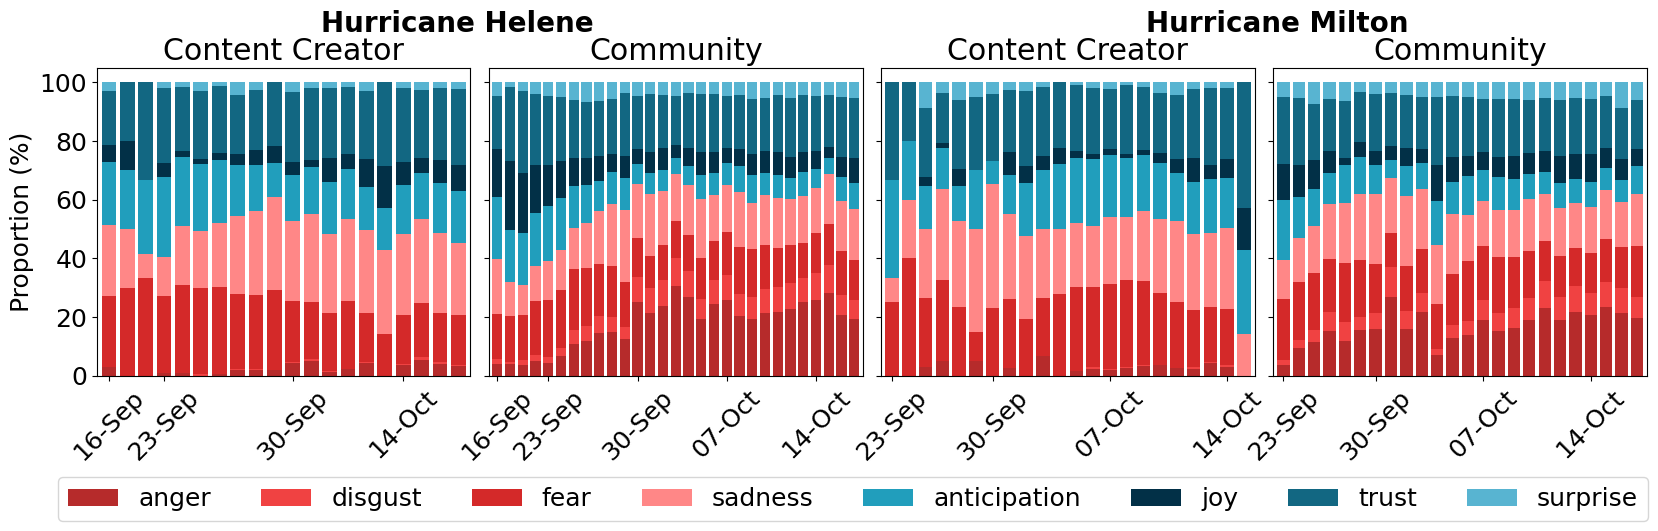

In [21]:
# Plot emotions
df_helene_transcripts_grouped_emo = df_helene_transcripts_grouped4.groupby(['date'])[plutchik].sum().reset_index()
df_milton_transcripts_grouped_emo = df_milton_transcripts_grouped4.groupby(['date'])[plutchik].sum().reset_index()
df_helene_comments_grouped_emo = df_helene_comments_grouped_topic_emo.groupby(['date'])[plutchik].sum().reset_index()
df_milton_comments_grouped_emo = df_milton_comments_grouped_topic_emo.groupby(['date'])[plutchik].sum().reset_index()

plot_stack100(
    df_helene_transcripts_grouped_emo[(df_helene_transcripts_grouped_emo.date >= '2024-09-16') & (df_helene_transcripts_grouped_emo.date <= '2024-10-17')],
    df_helene_comments_grouped_emo[(df_helene_comments_grouped_emo.date >= '2024-09-16') & (df_helene_comments_grouped_emo.date <= '2024-10-17')],
    df_milton_transcripts_grouped_emo[(df_milton_transcripts_grouped_emo.date >= '2024-09-23') & (df_milton_transcripts_grouped_emo.date <= '2024-10-17')],
    df_milton_comments_grouped_emo[(df_milton_comments_grouped_emo.date >= '2024-09-23') & (df_milton_comments_grouped_emo.date <= '2024-10-17')],
    'emotions'
    )

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_29028/788763740.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


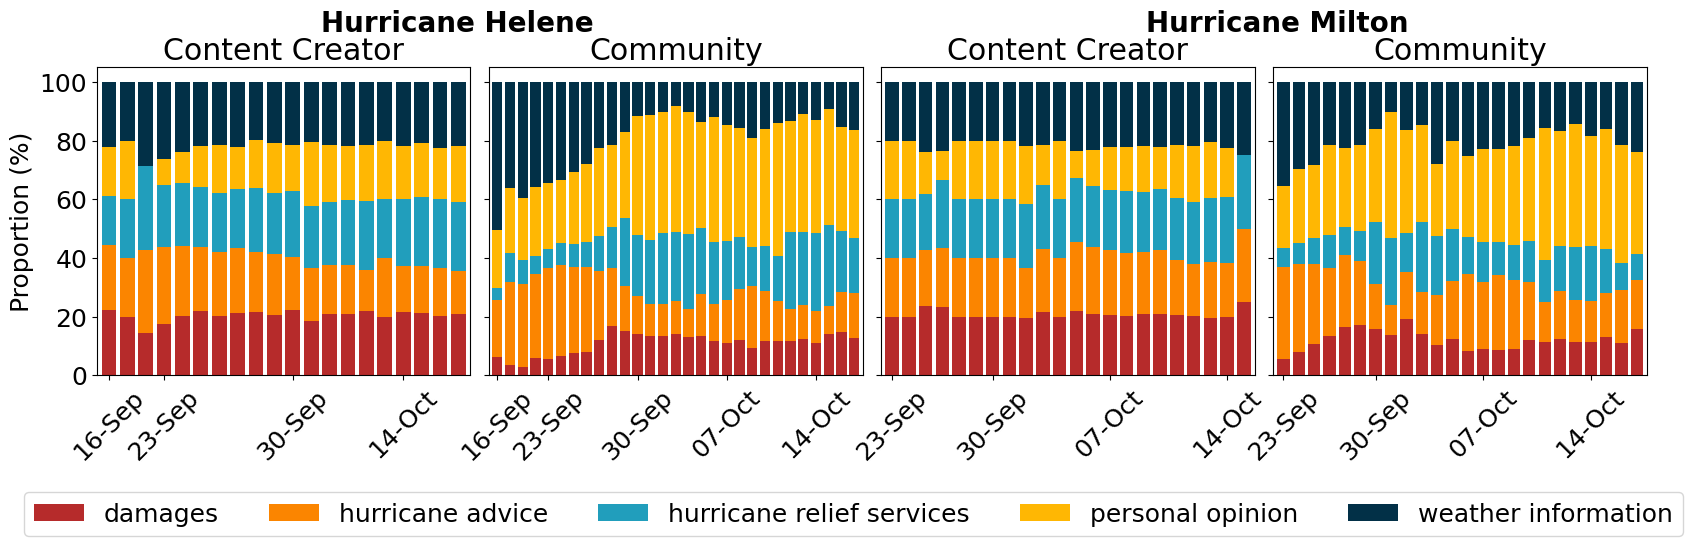

In [56]:
# Plot topics
df_milton_transcripts_topics = deepcopy(df_milton_transcripts3)
df_helene_transcripts_topics = deepcopy(df_helene_transcripts3)
df_milton_commentThreads_topics = deepcopy(df_milton_commentThreads3)
df_helene_commentThreads_topics = deepcopy(df_helene_commentThreads3)
df_milton_commentThreadsreplies_topics = deepcopy(df_milton_commentThreadsreplies3)
df_helene_commentThreadsreplies_topics = deepcopy(df_helene_commentThreadsreplies3)
df_milton_comments_topics = pd.concat([df_milton_commentThreads_topics, df_milton_commentThreadsreplies_topics]).reset_index(drop=True)
df_helene_comments_topics = pd.concat([df_helene_commentThreads_topics, df_helene_commentThreadsreplies_topics]).reset_index(drop=True)

for i in topic_list:
    df_milton_transcripts_topics[f"{i}"] = np.where(df_milton_transcripts_topics[f"topics_corrected"]==i, 1, 0)
    df_helene_transcripts_topics[f"{i}"] = np.where(df_helene_transcripts_topics[f"topics_corrected"]==i, 1, 0)
    df_milton_comments_topics[f"{i}"] = np.where(df_milton_comments_topics[f"topics_corrected"]==i, 1, 0)
    df_helene_comments_topics[f"{i}"] = np.where(df_helene_comments_topics[f"topics_corrected"]==i, 1, 0)

df_helene_transcripts_grouped_topics = df_helene_transcripts_topics.groupby(['date'])[topic_list].sum().reset_index()
df_milton_transcripts_grouped_topics = df_milton_transcripts_topics.groupby(['date'])[topic_list].sum().reset_index()
df_helene_comments_grouped_topics = df_helene_comments_topics.groupby(['date'])[topic_list].sum().reset_index()
df_milton_comments_grouped_topics = df_milton_comments_topics.groupby(['date'])[topic_list].sum().reset_index()

plot_stack100(
    df_helene_transcripts_grouped_topics[(df_helene_transcripts_grouped_topics.date >= '2024-09-16') & (df_helene_transcripts_grouped_topics.date <= '2024-10-17')],
    df_helene_comments_grouped_topics[(df_helene_comments_grouped_topics.date >= '2024-09-16') & (df_helene_comments_grouped_topics.date <= '2024-10-17')],
    df_milton_transcripts_grouped_topics[(df_milton_transcripts_grouped_topics.date >= '2024-09-23') & (df_milton_transcripts_grouped_topics.date <= '2024-10-17')],
    df_milton_comments_grouped_topics[(df_milton_comments_grouped_topics.date >= '2024-09-23') & (df_milton_comments_grouped_topics.date <= '2024-10-17')],
    'topics',
    legend_add_gap=-0.05
    )

In [58]:
# Get percentage of topics
df_helene_transcripts_grouped_topics['total'] = df_helene_transcripts_grouped_topics[topic_list].sum(axis=1)
df_milton_transcripts_grouped_topics['total'] = df_milton_transcripts_grouped_topics[topic_list].sum(axis=1)
df_helene_comments_grouped_topics['total'] = df_helene_comments_grouped_topics[topic_list].sum(axis=1)
df_milton_comments_grouped_topics['total'] = df_milton_comments_grouped_topics[topic_list].sum(axis=1)

for i in topic_list:
    df_helene_transcripts_grouped_topics[f"{i}_percent"] = df_helene_transcripts_grouped_topics[f"{i}"] / df_helene_transcripts_grouped_topics['total']
    df_milton_transcripts_grouped_topics[f"{i}_percent"] = df_milton_transcripts_grouped_topics[f"{i}"] / df_milton_transcripts_grouped_topics['total']
    df_helene_comments_grouped_topics[f"{i}_percent"] = df_helene_comments_grouped_topics[f"{i}"] / df_helene_comments_grouped_topics['total']
    df_milton_comments_grouped_topics[f"{i}_percent"] = df_milton_comments_grouped_topics[f"{i}"] / df_milton_comments_grouped_topics['total']

In [40]:
print("Helene Transcripts")
for i in topic_list:
    print(f"{i} {np.mean(df_helene_transcripts_grouped_topics[f'{i}_percent'])*100:.2f}%")
print("Milton Transcripts")
for i in topic_list:
    print(f"{i} {np.mean(df_milton_transcripts_grouped_topics[f'{i}_percent'])*100:.2f}%")
print("Helene Comments")
for i in topic_list:
    print(f"{i} {np.mean(df_helene_comments_grouped_topics[f'{i}_percent'])*100:.2f}%")
print("Milton Comments")
for i in topic_list:
    print(f"{i} {np.mean(df_milton_comments_grouped_topics[f'{i}_percent'])*100:.2f}%")

Helene Transcripts
damages 19.27%
hurricane advice 16.91%
hurricane relief services 20.88%
personal opinion 15.97%
weather information 20.57%
other 6.39%
Milton Transcripts
damages 19.15%
hurricane advice 19.32%
hurricane relief services 19.27%
personal opinion 15.26%
weather information 21.14%
other 5.86%
Helene Comments
damages 8.77%
hurricane advice 11.88%
hurricane relief services 12.53%
personal opinion 22.32%
weather information 13.56%
other 30.94%
Milton Comments
damages 9.87%
hurricane advice 14.33%
hurricane relief services 9.40%
personal opinion 21.29%
weather information 15.17%
other 29.93%


In [54]:
(6.39 + 5.86) / 2

6.125

In [55]:
(30.94 + 29.93) / 2

30.435000000000002

In [48]:
topics = set(
    list(df_milton_transcripts3['topics'].unique()) + 
    list(df_helene_transcripts3['topics'].unique()) +
    list(df_milton_commentThreads3['topics'].unique()) +
    list(df_helene_commentThreads3['topics'].unique()) +
    list(df_milton_commentThreadsreplies3['topics'].unique()) +
    list(df_helene_commentThreadsreplies3['topics'].unique())
)
len(topics)

1500

In [52]:
alltopics_df = pd.concat([
    df_milton_transcripts3[['topics', 'topics_corrected']],
    df_helene_transcripts3[['topics', 'topics_corrected']],
    df_milton_commentThreads3[['topics', 'topics_corrected']],
    df_helene_commentThreads3[['topics', 'topics_corrected']],
    df_milton_commentThreadsreplies3[['topics', 'topics_corrected']],
    df_helene_commentThreadsreplies3[['topics', 'topics_corrected']],
])

alltopics_df.groupby('topics_corrected').agg(distinct_topics=('topics', 'nunique')).reset_index().sort_values('topics_corrected')

,topics_corrected,distinct_topics
0,damages,119
1,hurricane advice,59
2,hurricane relief services,158
3,other,2
4,personal opinion,1066
5,weather information,118


## Emotion Polarity Index

In [ ]:
def ei(
    data: pd.DataFrame,
    type: str
) -> pd.DataFrame:

    df = deepcopy(data)

    pos_emo = ['anticipation', 'joy', 'trust', 'surprise']
    neg_emo = ['anger', 'disgust', 'fear', 'sadness']

    # Sum by row for each group
    df['positive'] = df[pos_emo].sum(axis=1)
    df['negative'] = df[neg_emo].sum(axis=1)

    # Calculate EPI
    df[f'ei_{type}'] = (df['positive'] - df['negative']) / (df['positive'] + df['negative'])

    return df

def epi(
    data_transcripts: pd.DataFrame,
    data_comments: pd.DataFrame,
    epsilon = 1e-6
):
    df_transcripts = deepcopy(data_transcripts)
    df_comments = deepcopy(data_comments)

    # Convert to datetime
    df_transcripts['date'] = pd.to_datetime(df_transcripts['date'])
    df_comments['date'] = pd.to_datetime(df_comments['date'])

    # Merge two tables keep all dates and set missing values to 0
    df = pd.merge(df_transcripts[['date', 'ei_creator']], df_comments[['date', 'ei_community']], on='date', how='outer').fillna(0)

    # Compute AEPI with Magnitude Scaling
    agreement_score = 1 - 2 * abs((df['ei_creator'] - df['ei_community']) / 
                                (abs(df['ei_creator']) + abs(df['ei_community']) + epsilon))

    # Magnitude weight based on the size of epi values
    magnitude_weight = (abs(df['ei_creator']) + abs(df['ei_community'])) *1.25

    # Final AEPI calculation
    df['epi'] = agreement_score * magnitude_weight

    # Limit AEPI between -1 and 1
    df['epi'] = np.clip(df['epi'], -1, 1)
    #df['epi'] = (2 * (df['epi'] - df['epi'].min()) / ((df['epi'].max()) - (df['epi'].min()))) - 1

    # Cases where there the epi_creator or epi_community is 0 set aepi to 0
    #df['epi'] = np.where((df['ei_creator'] == 0) | (df['ei_community'] == 0), 0, df['epi'])

    return df.drop_duplicates(subset=['date'], keep='first')


In [124]:
df_milton_transcripts_ei = ei(df_helene_transcripts_grouped_emo, 'creator')
df_helene_transcripts_ei = ei(df_milton_transcripts_grouped_emo, 'creator')
df_milton_comments_ei = ei(df_helene_comments_grouped_emo, 'community')
df_helene_comments_ei = ei(df_milton_comments_grouped_emo, 'community')

In [125]:
df_milton_epi = epi(df_milton_transcripts_ei, df_milton_comments_ei)
df_helene_epi = epi(df_helene_transcripts_ei, df_helene_comments_ei)

In [126]:
def epi_plot(
    helene: pd.DataFrame,
    milton: pd.DataFrame,
):

    df1 = deepcopy(helene)
    df2 = deepcopy(milton)

    # Convert 'date' column to datetime format
    df1['date'] = pd.to_datetime(df1['date'], format='%Y-%m-%d')
    df2['date'] = pd.to_datetime(df2['date'], format='%Y-%m-%d')

    plt.rcParams.update({'font.size': 20})

    # Create figure with two subplots (side by side)
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(20, 5), sharey=True, gridspec_kw={'wspace': 0.05})

    # --- First Graph: Milton ---
    ax1.plot(df1['date'], df1['ei_creator'], linestyle='--', color='b', label="Creator EI", linewidth=2)
    ax1.plot(df1['date'], df1['ei_community'], linestyle='--', color='g', label="Community EI", linewidth=2)
    ax1.plot(df1['date'], df1['epi'], linestyle='-', color='r', label="EPI", linewidth=4)
    ax1.set_title("Hurricane Helene")
    ax1.set_ylim(-1, 1)

    # --- Second Graph: AEPI ---
    ax3.plot(df2['date'], df2['ei_creator'], linestyle='--', color='b', label="Creator EI", linewidth=2)
    ax3.plot(df2['date'], df2['ei_community'], linestyle='--', color='g', label="Community EI", linewidth=2)
    ax3.plot(df2['date'], df2['epi'], linestyle='-', color='r', label="EPI", linewidth=4)
    ax3.set_title("Hurricane Milton")
    ax3.set_ylim(-1, 1)

    # Highlight Hurricane Helene (24 Sep - 27 Sep)
    ax1.axvspan(pd.to_datetime('2024-09-24'), pd.to_datetime('2024-09-27'), color='gray', alpha=0.3)
    ax3.axvspan(pd.to_datetime('2024-09-24'), pd.to_datetime('2024-09-27'), color='gray', alpha=0.3)
    ax1.text(pd.to_datetime('2024-09-23'), -0.95, "Helene", color='black', ha='left')
    ax3.text(pd.to_datetime('2024-09-24'), -0.95, "Helene", color='black', ha='left')

    # Highlight Hurricane Milton (5 Oct - 10 Oct)
    ax1.axvspan(pd.to_datetime('2024-10-05'), pd.to_datetime('2024-10-10'), color='gray', alpha=0.3)
    ax3.axvspan(pd.to_datetime('2024-10-05'), pd.to_datetime('2024-10-10'), color='gray', alpha=0.3)
    ax1.text(pd.to_datetime('2024-10-07'), -0.95, "Milton", color='black', ha='center')
    ax3.text(pd.to_datetime('2024-10-06'), -0.95, "Milton", color='black', ha='left')

    # Formatting
    week_start_dates = df1['date'].dt.to_period('W').drop_duplicates().dt.start_time  # Get start of each week
    ax1.set_xticks(week_start_dates)  # Set ticks at these dates
    ax1.set_xticklabels(week_start_dates.dt.strftime('%d-%b'))  # Format labels correctly 
    week_start_dates = df2['date'].dt.to_period('W').drop_duplicates().dt.start_time  # Get start of each week
    ax3.set_xticks(week_start_dates)  # Set ticks at these dates
    ax3.set_xticklabels(week_start_dates.dt.strftime('%d-%b'))  # Format labels correctly 

    plt.xticks(rotation=360)  # Rotate x-ticks for better readability

    # Remove x-axis label
    ax1.set_ylabel('Index')

    # Combine legends from both graphs and place at the bottom outside the plot
    lines1, labels1 = ax1.get_legend_handles_labels()
    fig.legend(lines1, labels1, loc="upper right", bbox_to_anchor=(0.9, 0.9), ncol=1, fontsize=20)

    # Adjust layout to ensure everything fits
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    # Show plot
    plt.show()

In [128]:
df_helene_epi.loc[(df_helene_epi['ei_community']<0) & (df_helene_epi['epi']>0), 'epi'] = -1 * df_helene_epi['epi']

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_29028/442701606.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


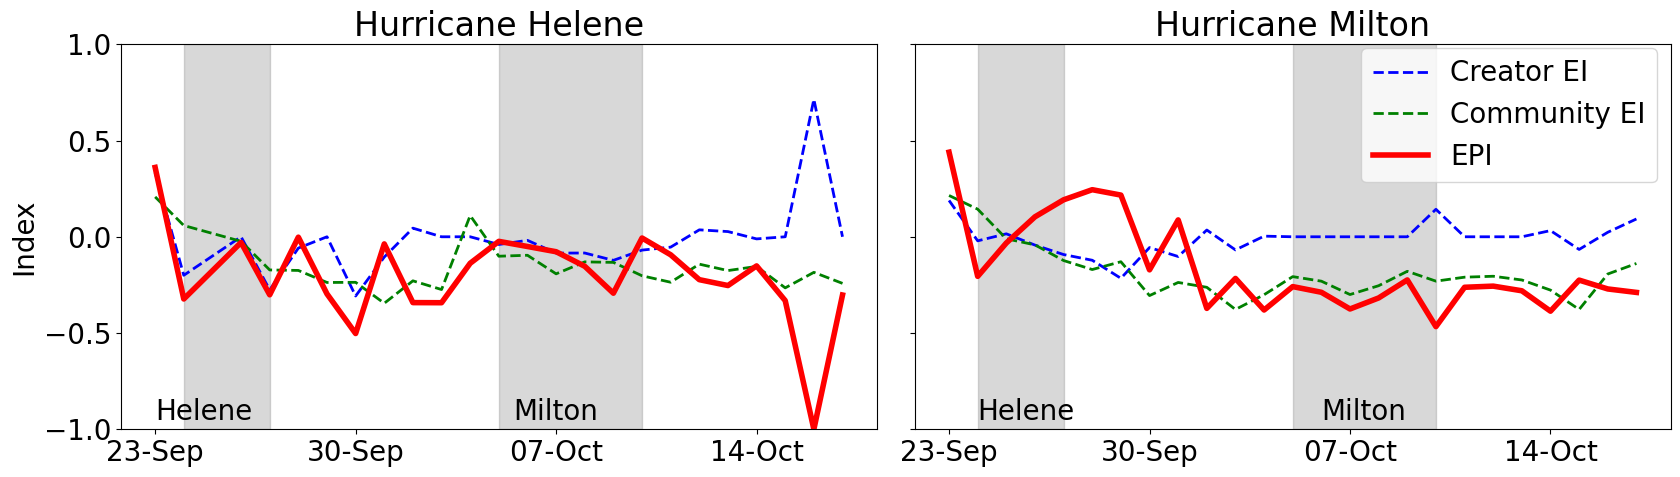

In [129]:
epi_plot(
    df_helene_epi[(df_helene_epi.date >= '2024-09-16') & (df_helene_epi.date <= '2024-10-17')],
    df_milton_epi[(df_milton_epi.date >= '2024-09-23') & (df_milton_epi.date <= '2024-10-17')]
)

In [479]:
pos_emo = ['anticipation', 'joy', 'trust', 'surprise']
neg_emo = ['anger', 'disgust', 'fear', 'sadness']

df_helene_transcripts_grouped['percent_neg'] = 100*df_helene_transcripts_grouped[neg_emo].sum(axis=1) / df_helene_transcripts_grouped[neg_emo + pos_emo].sum(axis=1)
df_helene_comments_grouped2['percent_neg'] = 100*df_helene_comments_grouped2[neg_emo].sum(axis=1) / df_helene_comments_grouped2[neg_emo + pos_emo].sum(axis=1)
df_milton_transcripts_grouped['percent_neg'] = 100*df_milton_transcripts_grouped[neg_emo].sum(axis=1) / df_milton_transcripts_grouped[neg_emo + pos_emo].sum(axis=1)
df_milton_comments_grouped2['percent_neg'] = 100*df_milton_comments_grouped2[neg_emo].sum(axis=1) / df_milton_comments_grouped2[neg_emo + pos_emo].sum(axis=1)

df_helene_transcripts_grouped['percent_pos'] = 100 - df_helene_transcripts_grouped['percent_neg']
df_helene_comments_grouped2['percent_pos'] = 100 - df_helene_comments_grouped2['percent_neg']
df_milton_transcripts_grouped['percent_pos'] = 100 - df_milton_transcripts_grouped['percent_neg']
df_milton_comments_grouped2['percent_pos'] = 100 - df_milton_comments_grouped2['percent_neg']

In [483]:
np.mean([63.366337, 60.938578, 73.156342, 73.415765, 64.850136, 65.816775, 61.521050, 59.469496])

np.float64(65.316809875)

In [484]:
np.mean([57.310968, 57.357308, 51.610658, 53.598862])

np.float64(54.969449)

In [499]:
np.mean([
    np.mean(df_helene_comments_grouped2.loc[
        (df_helene_comments_grouped2.date > '2024-09-27') & (df_helene_comments_grouped2.date <= '2024-10-04')
        , 'percent_neg']),
    np.mean(df_milton_comments_grouped2.loc[
    (df_milton_comments_grouped2.date > '2024-10-10') & (df_milton_comments_grouped2.date <= '2024-10-17')
    , 'percent_neg'])
])

np.float64(56.979474600944684)

In [498]:
np.mean(df_milton_comments_grouped2.loc[
    (df_milton_comments_grouped2.date > '2024-10-10') & (df_milton_comments_grouped2.date <= '2024-10-17')
    , 'percent_neg'])

np.float64(56.68999656110544)

In [504]:
np.mean([
    np.mean(df_milton_transcripts_grouped['percent_pos']),
    np.mean(df_helene_transcripts_grouped['percent_pos'])
])

np.float64(57.03859845975484)

In [ ]:
np.mean([
    np.mean(df_milton_comments_grouped2['percent_neg']),
    np.mean(df_helene_comments_grouped2['percent_neg'])
])

np.float64(51.34428101213323)

In [523]:
(
    np.min([
        np.min(df_helene_aepi.loc[
            (df_helene_aepi.date >= '2024-09-16') & (df_helene_aepi.date < '2024-09-24') & (df_helene_aepi.aepi != 0)
            , 'aepi']),
        np.min(df_milton_aepi.loc[
        (df_milton_aepi.date >= '2024-10-04') & (df_milton_aepi.date < '2024-10-05') & (df_milton_aepi.aepi != 0)
        , 'aepi'])
    ]),
    np.max([
        np.max(df_helene_aepi.loc[
            (df_helene_aepi.date >= '2024-09-16') & (df_helene_aepi.date <= '2024-10-17') &
            (df_helene_aepi.date < '2024-09-24') & (df_helene_aepi.aepi != 0)
            , 'aepi']),
        np.max(df_milton_aepi.loc[
        (df_milton_aepi.date >= '2024-09-23') & (df_milton_aepi.date <= '2024-10-17') &
        (df_milton_aepi.date < '2024-10-05') & (df_milton_aepi.date > '2024-09-27') & (df_milton_aepi.aepi != 0)
        , 'aepi'])
    ]),
)

(np.float64(0.0560030015916515), np.float64(0.8010682807124363))

In [518]:
(
    np.min([
        np.min(df_helene_aepi.loc[
            (df_helene_aepi.date > '2024-09-27') & (df_helene_aepi.date <= '2024-10-04') & (df_helene_aepi.aepi != 0)
            , 'aepi']),
        np.min(df_milton_aepi.loc[
        (df_milton_aepi.date > '2024-10-10') & (df_milton_aepi.date <= '2024-10-17') & (df_milton_aepi.aepi != 0)
        , 'aepi'])
    ]),
    np.max([
        np.max(df_helene_aepi.loc[
            (df_helene_aepi.date >= '2024-09-27') & (df_helene_aepi.date <= '2024-10-04') & (df_helene_aepi.aepi != 0)
            , 'aepi']),
        np.max(df_milton_aepi.loc[
        (df_milton_aepi.date > '2024-10-10') & (df_milton_aepi.date <= '2024-10-17') & (df_milton_aepi.aepi != 0)
        , 'aepi'])
    ]),
)

(np.float64(-0.5923306754005668), np.float64(0.05193653545559829))

In [147]:
def ei_topic(
    data: pd.DataFrame,
    type: str,
):
    df = deepcopy(data)

    pos_emo = ['anticipation', 'joy', 'trust', 'surprise']
    neg_emo = ['anger', 'disgust', 'fear', 'sadness']

    all_dfs = []

    # Calculate EPI
    for i in topic_list:
        topic_df = df[df['topics_corrected'] == i]
        topic_df['positive'] = topic_df[pos_emo].sum(axis=1)
        topic_df['negative'] = topic_df[neg_emo].sum(axis=1)
        topic_df[f'ei_{type}_{i}'] = (topic_df['positive'] - topic_df['negative']) / (topic_df['positive'] + topic_df['negative'])

        all_dfs.append(topic_df[['date', f'ei_{type}_{i}']])
    
    df_out = all_dfs[0]
    for i in range(1, len(all_dfs)):
        df_out = pd.merge(df_out, all_dfs[i], on='date', how='outer').fillna(0)
        
    return df_out

def epi_topic(
    data_transcripts: pd.DataFrame,
    data_comments: pd.DataFrame,
    epsilon = 1e-6
):
    df_transcripts = deepcopy(data_transcripts)
    df_comments = deepcopy(data_comments)

    # Convert to datetime
    df_transcripts['date'] = pd.to_datetime(df_transcripts['date'])
    df_comments['date'] = pd.to_datetime(df_comments['date'])

    # Merge two tables keep all dates and set missing values to 0
    df = pd.merge(df_transcripts, df_comments, on='date', how='outer').fillna(0)

    # Compute AEPI with Magnitude Scaling
    for i in topic_list:
        agreement_score = 1 - 2 * abs((df[f'ei_creator_{i}'] - df[f'ei_community_{i}']) / 
                                    (abs(df[f'ei_creator_{i}']) + abs(df[f'ei_community_{i}']) + epsilon))

        # Magnitude weight based on the size of epi values
        magnitude_weight = (abs(df[f'ei_creator_{i}']) + abs(df[f'ei_community_{i}'])) * 1.25

        # Final AEPI calculation
        df[f'epi_{i}'] = agreement_score * magnitude_weight

        # Limit AEPI between -1 and 1
        df[f'epi_{i}'] = np.clip(df[f'epi_{i}'], -1, 1)
    #df['epi'] = (2 * (df['epi'] - df['epi'].min()) / ((df['epi'].max()) - (df['epi'].min()))) - 1

    # Cases where there the epi_creator or epi_community is 0 set aepi to 0
    #df['epi'] = np.where((df['ei_creator'] == 0) | (df['ei_community'] == 0), 0, df['epi'])

    return df.drop_duplicates(subset=['date'], keep='first')

In [140]:
df_milton_transcripts_ei = ei_topic(df_milton_transcripts_grouped4, 'creator')
df_helene_transcripts_ei = ei_topic(df_helene_transcripts_grouped4, 'creator')
df_milton_comments_ei = ei_topic(df_milton_comments_grouped_topic_emo, 'community')
df_helene_comments_ei = ei_topic(df_helene_comments_grouped_topic_emo, 'community')

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_29028/1903155701.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topic_df['positive'] = topic_df[pos_emo].sum(axis=1)
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_29028/1903155701.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topic_df['negative'] = topic_df[neg_emo].sum(axis=1)
/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_29028/1903155701.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of

In [149]:
df_milton_epi = epi_topic(df_milton_transcripts_ei, df_milton_comments_ei)
df_helene_epi = epi_topic(df_milton_transcripts_ei, df_milton_comments_ei)

In [164]:
def plot_ei_topic(
    data1: pd.DataFrame,
    data2: pd.DataFrame,
    data3: pd.DataFrame,
    data4: pd.DataFrame,
    legend_cols: int = 8,
    legend_add_gap: float = 0.0
):

    df1 = deepcopy(data1)
    df2 = deepcopy(data2)
    df3 = deepcopy(data3)
    df4 = deepcopy(data4)
    df1 = df1[['date'] + [f"ei_creator_{i}" for i in topic_list if i!='other']]
    df2 = df2[['date'] + [f"ei_community_{i}" for i in topic_list if i!='other']]
    df3 = df3[['date'] + [f"ei_creator_{i}" for i in topic_list if i!='other']]
    df4 = df4[['date'] + [f"ei_community_{i}" for i in topic_list if i!='other']]

    # Set 'date' as index
    df1['date'] = pd.to_datetime(df1['date'], format='%Y-%m-%d')
    df2['date'] = pd.to_datetime(df2['date'], format='%Y-%m-%d')
    df3['date'] = pd.to_datetime(df3['date'], format='%Y-%m-%d')
    df4['date'] = pd.to_datetime(df4['date'], format='%Y-%m-%d')

    plt.rcParams.update({'font.size': 18})

    # Create figure with two subplots (side by side)
    fig, (ax1, ax3, ax5, ax7) = plt.subplots(1, 4, figsize=(20, 4), sharey=True, gridspec_kw={'wspace': 0.05})

    # Plot
    for i in topic_list:
        if i != 'other':
            ax1.plot(df1['date'], df1[f'ei_creator_{i}'], color=topiccolours[i], label=i, linewidth=2)
            ax3.plot(df2['date'], df2[f'ei_community_{i}'], color=topiccolours[i], label=i, linewidth=2)
            ax5.plot(df3['date'], df3[f'ei_creator_{i}'], color=topiccolours[i], label=i, linewidth=2)
            ax7.plot(df4['date'], df4[f'ei_community_{i}'], color=topiccolours[i], label=i, linewidth=2)

    # Formatting
    ax1.set_xlabel("")
    ax3.set_xlabel("")
    ax5.set_xlabel("")
    ax7.set_xlabel("")
    ax1.set_ylabel('Index')

    # Format x-axis dates as 'DD-Mon'
    week_start_dates = df1['date'].dt.to_period('W').drop_duplicates().dt.start_time  # Get start of each week
    ax1.set_xticks(week_start_dates)  # Set ticks at these dates
    ax1.set_xticklabels(week_start_dates.dt.strftime('%d-%b'))  # Format labels correctly 
    week_start_dates = df2['date'].dt.to_period('W').drop_duplicates().dt.start_time  # Get start of each week
    ax3.set_xticks(week_start_dates)  # Set ticks at these dates
    ax3.set_xticklabels(week_start_dates.dt.strftime('%d-%b'))  # Format labels correctly 
    week_start_dates = df3['date'].dt.to_period('W').drop_duplicates().dt.start_time  # Get start of each week
    ax5.set_xticks(week_start_dates)  # Set ticks at these dates
    ax5.set_xticklabels(week_start_dates.dt.strftime('%d-%b'))  # Format labels correctly
    week_start_dates = df4['date'].dt.to_period('W').drop_duplicates().dt.start_time  # Get start of each week
    ax7.set_xticks(week_start_dates)  # Set ticks at these dates
    ax7.set_xticklabels(week_start_dates.dt.strftime('%d-%b'))  # Format labels correctly 

    ax1.set_title('Content Creator')
    ax3.set_title('Community')
    ax5.set_title('Content Creator')
    ax7.set_title('Community')

    # # Turn off legends for all ax
    # ax1.get_legend().remove()
    # ax3.get_legend().remove()
    # ax5.get_legend().remove()
    # ax7.get_legend().remove()

    # Add shared titles for groups
    fig.text(0.305, 0.97, "Hurricane Helene", ha='center', fontsize=20, fontweight='bold')
    fig.text(0.715, 0.97, "Hurricane Milton", ha='center', fontsize=20, fontweight='bold')
    
    # Rotate x-axis labels
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45)
    plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45)

    # Move legend outside
    plt.legend(title="", bbox_to_anchor=(-1.125, -0.4+legend_add_gap), ncol=legend_cols, loc='center', fontsize='18')

    plt.tight_layout()

    # Show plot
    plt.show()

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_29028/1956142152.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


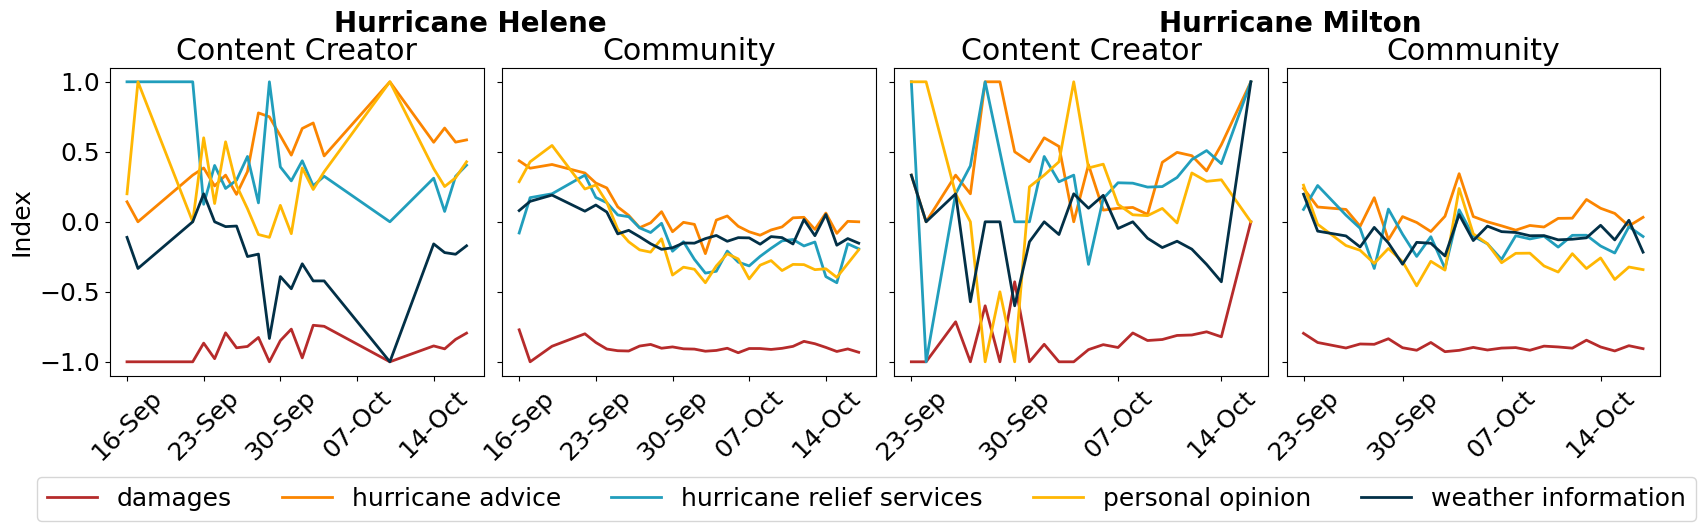

In [165]:
plot_ei_topic(
    df_helene_transcripts_ei[(df_helene_transcripts_ei.date >= '2024-09-16') & (df_helene_transcripts_ei.date <= '2024-10-17')],
    df_helene_comments_ei[(df_helene_comments_ei.date >= '2024-09-16') & (df_helene_comments_ei.date <= '2024-10-17')],
    df_milton_transcripts_ei[(df_milton_transcripts_ei.date >= '2024-09-23') & (df_milton_transcripts_ei.date <= '2024-10-17')],
    df_milton_comments_ei[(df_milton_comments_ei.date >= '2024-09-23') & (df_milton_comments_ei.date <= '2024-10-17')]
)

In [186]:
# Create weights
helene_creator_weights = df_helene_transcripts_grouped_topics[['date']+[f"{i}_percent" for i in topic_list if i != 'other']]
milton_creator_weights = df_milton_transcripts_grouped_topics[['date']+[f"{i}_percent" for i in topic_list if i != 'other']]
helene_community_weights = df_helene_comments_grouped_topics[['date']+[f"{i}_percent" for i in topic_list if i != 'other']]
milton_community_weights = df_milton_comments_grouped_topics[['date']+[f"{i}_percent" for i in topic_list if i != 'other']]

# Rename columns
helene_creator_weights.columns = ['date'] + [f"creator_{i}_percent" for i in topic_list if i != 'other']
milton_creator_weights.columns = ['date'] + [f"creator_{i}_percent" for i in topic_list if i != 'other']
helene_community_weights.columns = ['date'] + [f"community_{i}_percent" for i in topic_list if i != 'other']
milton_community_weights.columns = ['date'] + [f"community_{i}_percent" for i in topic_list if i != 'other']

# Merge datasets
df_helene_epi_weights = pd.merge(df_helene_epi, helene_creator_weights, on='date', how='outer').fillna(0)
df_milton_epi_weights = pd.merge(df_milton_epi, milton_creator_weights, on='date', how='outer').fillna(0)
df_helene_epi_weights = pd.merge(df_helene_epi_weights, helene_community_weights, on='date', how='outer').fillna(0)
df_milton_epi_weights = pd.merge(df_milton_epi_weights, milton_community_weights, on='date', how='outer').fillna(0)

# Calculate weighted EPI
for i in topic_list:
    if i != 'other':
        df_helene_epi_weights[f'epi_{i}_weighted'] = df_helene_epi_weights[f'epi_{i}'] * (df_helene_epi_weights[f'creator_{i}_percent'] + df_helene_epi_weights[f'community_{i}_percent'])
        df_milton_epi_weights[f'epi_{i}_weighted'] = df_milton_epi_weights[f'epi_{i}'] * (df_milton_epi_weights[f'creator_{i}_percent'] + df_milton_epi_weights[f'community_{i}_percent'])

# Calculate total weighted EPI
df_helene_epi_weights['epi_weighted'] = df_helene_epi_weights[[f'epi_{i}_weighted' for i in topic_list if i != 'other']].sum(axis=1)
df_milton_epi_weights['epi_weighted'] = df_milton_epi_weights[[f'epi_{i}_weighted' for i in topic_list if i != 'other']].sum(axis=1)

df_helene_epi_weights['epi_weighted'] = np.clip(df_helene_epi_weights['epi_weighted'], -1, 1)
df_milton_epi_weights['epi_weighted'] = np.clip(df_milton_epi_weights['epi_weighted'], -1, 1)

In [191]:
def plot_epi_topic_weighted(
    helene: pd.DataFrame,
    milton: pd.DataFrame,
):

    df1 = deepcopy(helene)
    df2 = deepcopy(milton)

    # Convert 'date' column to datetime format
    df1['date'] = pd.to_datetime(df1['date'], format='%Y-%m-%d')
    df2['date'] = pd.to_datetime(df2['date'], format='%Y-%m-%d')

    plt.rcParams.update({'font.size': 20})

    # Create figure with two subplots (side by side)
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(20, 5), sharey=True, gridspec_kw={'wspace': 0.05})

    # --- First Graph: Milton ---
    ax1.plot(df1['date'], df1['epi_weighted'], linewidth=2)
    ax1.set_title("Hurricane Helene")
    ax1.set_ylim(-1, 1)

    # --- Second Graph: AEPI ---
    ax3.plot(df2['date'], df2['epi_weighted'], linewidth=2)
    ax3.set_title("Hurricane Milton")
    ax3.set_ylim(-1, 1)

    # Highlight Hurricane Helene (24 Sep - 27 Sep)
    ax1.axvspan(pd.to_datetime('2024-09-24'), pd.to_datetime('2024-09-27'), color='gray', alpha=0.3)
    ax3.axvspan(pd.to_datetime('2024-09-24'), pd.to_datetime('2024-09-27'), color='gray', alpha=0.3)
    ax1.text(pd.to_datetime('2024-09-23'), -0.95, "Helene", color='black', ha='left')
    ax3.text(pd.to_datetime('2024-09-24'), -0.95, "Helene", color='black', ha='left')

    # Highlight Hurricane Milton (5 Oct - 10 Oct)
    ax1.axvspan(pd.to_datetime('2024-10-05'), pd.to_datetime('2024-10-10'), color='gray', alpha=0.3)
    ax3.axvspan(pd.to_datetime('2024-10-05'), pd.to_datetime('2024-10-10'), color='gray', alpha=0.3)
    ax1.text(pd.to_datetime('2024-10-07'), -0.95, "Milton", color='black', ha='center')
    ax3.text(pd.to_datetime('2024-10-06'), -0.95, "Milton", color='black', ha='left')

    # Formatting
    week_start_dates = df1['date'].dt.to_period('W').drop_duplicates().dt.start_time  # Get start of each week
    ax1.set_xticks(week_start_dates)  # Set ticks at these dates
    ax1.set_xticklabels(week_start_dates.dt.strftime('%d-%b'))  # Format labels correctly 
    week_start_dates = df2['date'].dt.to_period('W').drop_duplicates().dt.start_time  # Get start of each week
    ax3.set_xticks(week_start_dates)  # Set ticks at these dates
    ax3.set_xticklabels(week_start_dates.dt.strftime('%d-%b'))  # Format labels correctly 

    plt.xticks(rotation=360)  # Rotate x-ticks for better readability

    # add horizontal line at y=0
    ax1.axhline(0, color='black', linewidth=2, linestyle='--')
    ax3.axhline(0, color='black', linewidth=2, linestyle='--')

    # Remove x-axis label
    ax1.set_ylabel('Index')

    # Adjust layout to ensure everything fits
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    # Show plot
    plt.show()

/var/folders/pr/x4pd5c4d2y94knncdskg53qm0000gn/T/ipykernel_29028/688200282.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


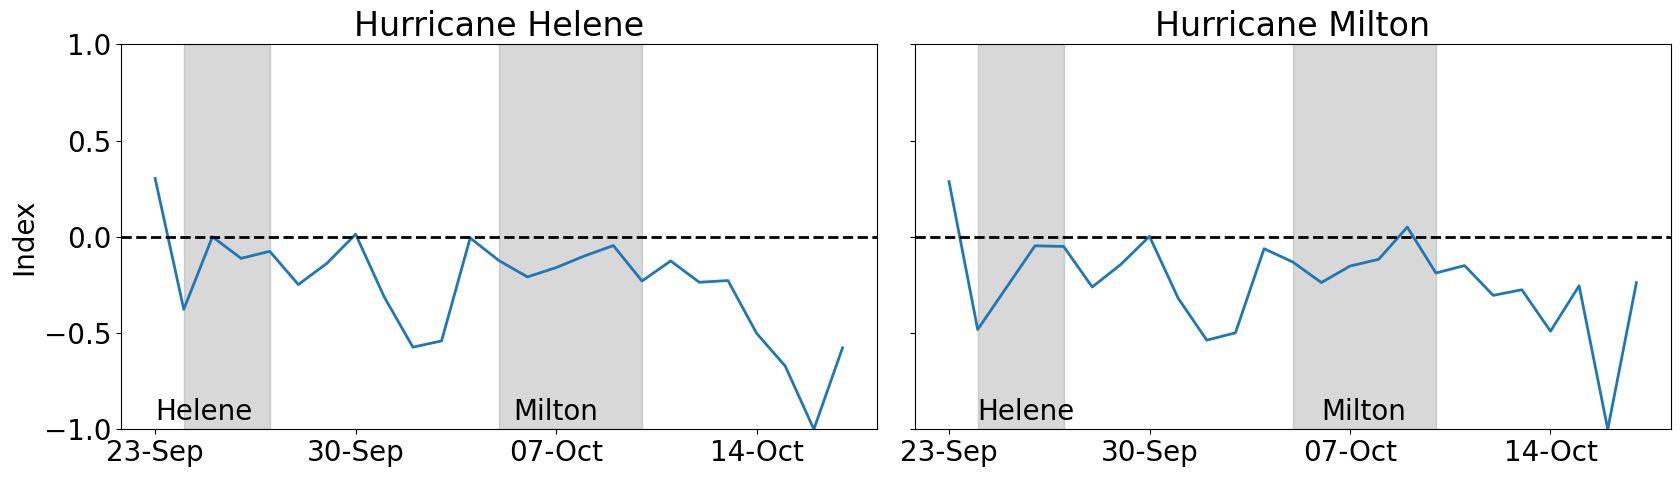

In [197]:
plot_epi_topic_weighted(
    df_helene_epi_weights[(df_helene_epi_weights.date >= '2024-09-23') & (df_helene_epi_weights.date <= '2024-10-17')],
    df_milton_epi_weights[(df_milton_epi_weights.date >= '2024-09-23') & (df_milton_epi_weights.date <= '2024-10-17')]
)